In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the Kalshi 100ms trade data
kalshi_df = pd.read_csv("data/games_live/20251021_GSW_LAL_kalshi_100ms.csv")
kalshi_df["timestamp"] = pd.to_datetime(kalshi_df["timestamp"], format="ISO8601")

# Load the PBP (play-by-play) data for scores
pbp_df = pd.read_csv("data/games_live/20251021_GSW_LAL.csv")
pbp_df["timeActual"] = pd.to_datetime(pbp_df["timeActual"], format="ISO8601")

print(f"Kalshi data: {len(kalshi_df)} rows")
print(f"PBP data: {len(pbp_df)} rows")
print(f"\nKalshi columns: {list(kalshi_df.columns)}")
print(f"\nFirst few Kalshi rows with trades:")
kalshi_df[kalshi_df["home_trades"] > 0].head()

Kalshi data: 88991 rows
PBP data: 565 rows

Kalshi columns: ['game_date', 'home_team', 'away_team', 'home_ticker', 'away_ticker', 'timestamp', 'home_high_cents', 'home_low_cents', 'home_volume', 'home_trades', 'away_high_cents', 'away_low_cents', 'away_volume', 'away_trades']

First few Kalshi rows with trades:


,game_date,home_team,away_team,home_ticker,away_ticker,timestamp,home_high_cents,home_low_cents,home_volume,home_trades,away_high_cents,away_low_cents,away_volume,away_trades
54,2025-10-21,Los Angeles Lakers,Golden State Warriors,KXNBAGAME-25OCT21GSWLAL-LAL,KXNBAGAME-25OCT21GSWLAL-GSW,2025-10-22 02:17:46.600000+00:00,0.44,0.44,113,1,NaN,NaN,0,0
55,2025-10-21,Los Angeles Lakers,Golden State Warriors,KXNBAGAME-25OCT21GSWLAL-LAL,KXNBAGAME-25OCT21GSWLAL-GSW,2025-10-22 02:17:46.700000+00:00,0.45,0.45,3,1,NaN,NaN,0,0
64,2025-10-21,Los Angeles Lakers,Golden State Warriors,KXNBAGAME-25OCT21GSWLAL-LAL,KXNBAGAME-25OCT21GSWLAL-GSW,2025-10-22 02:17:47.600000+00:00,0.45,0.45,21,1,NaN,NaN,0,0
76,2025-10-21,Los Angeles Lakers,Golden State Warriors,KXNBAGAME-25OCT21GSWLAL-LAL,KXNBAGAME-25OCT21GSWLAL-GSW,2025-10-22 02:17:48.800000+00:00,0.45,0.45,31,1,NaN,NaN,0,0
158,2025-10-21,Los Angeles Lakers,Golden State Warriors,KXNBAGAME-25OCT21GSWLAL-LAL,KXNBAGAME-25OCT21GSWLAL-GSW,2025-10-22 02:17:57+00:00,0.45,0.45,12000,1,NaN,NaN,0,0


In [3]:
# Forward-fill the price columns
# When there's no trade, use the last known price

# For home team prices
kalshi_df["home_high_cents_ffill"] = kalshi_df["home_high_cents"].ffill()
kalshi_df["home_low_cents_ffill"] = kalshi_df["home_low_cents"].ffill()

# For away team prices  
kalshi_df["away_high_cents_ffill"] = kalshi_df["away_high_cents"].ffill()
kalshi_df["away_low_cents_ffill"] = kalshi_df["away_low_cents"].ffill()

# Create a single "price" column using the midpoint of high/low, or just high if they're the same
kalshi_df["home_price"] = (kalshi_df["home_high_cents_ffill"] + kalshi_df["home_low_cents_ffill"]) / 2
kalshi_df["away_price"] = (kalshi_df["away_high_cents_ffill"] + kalshi_df["away_low_cents_ffill"]) / 2

print("After forward-fill:")
print(f"  Home price non-null: {kalshi_df['home_price'].notna().sum()} / {len(kalshi_df)}")
print(f"  Away price non-null: {kalshi_df['away_price'].notna().sum()} / {len(kalshi_df)}")

# Show some rows around a trade to verify forward-fill works
sample_idx = kalshi_df[kalshi_df["home_trades"] > 0].index[5]
kalshi_df.loc[sample_idx-3:sample_idx+3, ["timestamp", "home_high_cents", "home_high_cents_ffill", "home_trades"]]

After forward-fill:
  Home price non-null: 88937 / 88991
  Away price non-null: 88933 / 88991


,timestamp,home_high_cents,home_high_cents_ffill,home_trades
174,2025-10-22 02:17:58.600000+00:00,NaN,0.45,0
175,2025-10-22 02:17:58.700000+00:00,NaN,0.45,0
176,2025-10-22 02:17:58.800000+00:00,NaN,0.45,0
177,2025-10-22 02:17:58.900000+00:00,0.45,0.45,1
178,2025-10-22 02:17:59+00:00,NaN,0.45,0
179,2025-10-22 02:17:59.100000+00:00,NaN,0.45,0
180,2025-10-22 02:17:59.200000+00:00,NaN,0.45,0


In [4]:
# Extract score data from PBP and merge with Kalshi time series
# PBP has sporadic events; we need to forward-fill scores to match 100ms granularity

# Get only rows with valid scores (filter out header rows or nulls)
score_df = pbp_df[["timeActual", "scoreHome", "scoreAway"]].copy()
score_df = score_df.dropna(subset=["timeActual"])
score_df = score_df.sort_values("timeActual")

# Floor PBP timestamps to 100ms buckets to match Kalshi data
score_df["timestamp"] = score_df["timeActual"].dt.floor("100ms")

# Group by timestamp bucket and take the last score in each bucket
score_df = score_df.groupby("timestamp").last().reset_index()
score_df = score_df[["timestamp", "scoreHome", "scoreAway"]]

print(f"Score events: {len(score_df)}")
print(f"\nScore range: Home {score_df['scoreHome'].min()}-{score_df['scoreHome'].max()}, Away {score_df['scoreAway'].min()}-{score_df['scoreAway'].max()}")

# Merge scores into Kalshi dataframe
kalshi_df = kalshi_df.merge(score_df, on="timestamp", how="left")

# Forward-fill the scores (score stays same until next scoring event)
kalshi_df["scoreHome"] = kalshi_df["scoreHome"].ffill().fillna(0)
kalshi_df["scoreAway"] = kalshi_df["scoreAway"].ffill().fillna(0)

print(f"\nAfter merge and forward-fill:")
print(f"  Final score: Home {kalshi_df['scoreHome'].max():.0f} - Away {kalshi_df['scoreAway'].max():.0f}")

# Show sample with scores
kalshi_df[["timestamp", "home_price", "away_price", "scoreHome", "scoreAway"]].head(20)

Score events: 420

Score range: Home 0-109, Away 0-119

After merge and forward-fill:
  Final score: Home 109 - Away 119


,timestamp,home_price,away_price,scoreHome,scoreAway
0,2025-10-22 02:17:41.200000+00:00,NaN,NaN,0.0,0.0
1,2025-10-22 02:17:41.300000+00:00,NaN,NaN,0.0,0.0
2,2025-10-22 02:17:41.400000+00:00,NaN,NaN,0.0,0.0
3,2025-10-22 02:17:41.500000+00:00,NaN,NaN,0.0,0.0
4,2025-10-22 02:17:41.600000+00:00,NaN,NaN,0.0,0.0
5,2025-10-22 02:17:41.700000+00:00,NaN,NaN,0.0,0.0
6,2025-10-22 02:17:41.800000+00:00,NaN,NaN,0.0,0.0
7,2025-10-22 02:17:41.900000+00:00,NaN,NaN,0.0,0.0
8,2025-10-22 02:17:42+00:00,NaN,NaN,0.0,0.0
9,2025-10-22 02:17:42.100000+00:00,NaN,NaN,0.0,0.0


Plotting 601 rows
Time range: 2025-10-22 04:03:00+00:00 to 2025-10-22 04:04:00+00:00


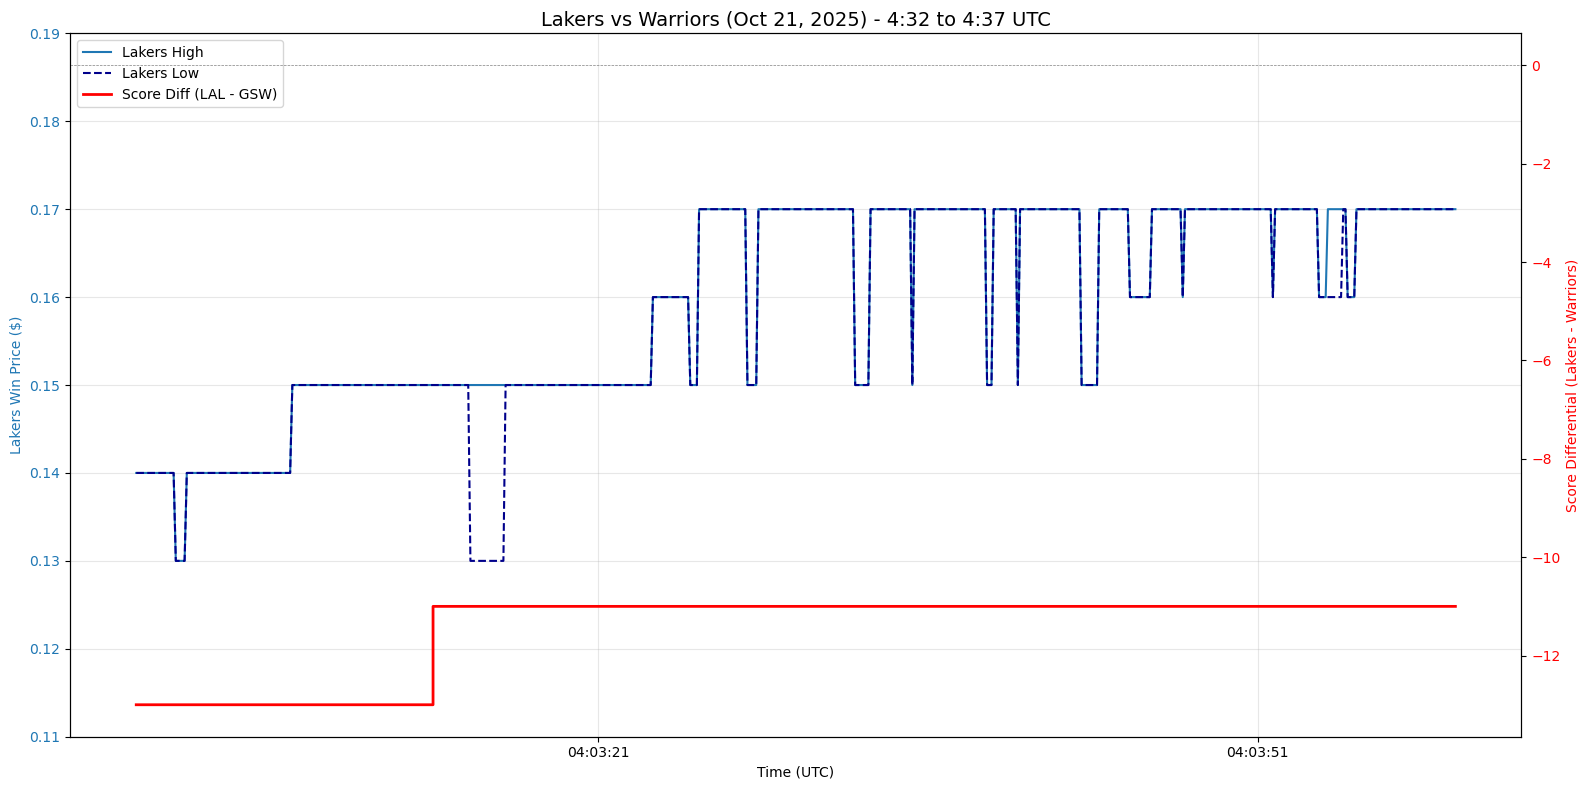


📊 Summary (4:32-4:37 UTC):
   Price: $0.13 - $0.17 (swing: $0.04)
   Score diff: -13 → -11
   Trades: 178


In [20]:
# Plot: Trading price + score differential
# Time range: 4:32 to 4:37 UTC

# Filter to specific time window
start_time = kalshi_df["timestamp"].iloc[0].replace(hour=4, minute=3, second=0, microsecond=0)
end_time = kalshi_df["timestamp"].iloc[0].replace(hour=4, minute=4, second=0, microsecond=0)

df_window = kalshi_df[(kalshi_df["timestamp"] >= start_time) & (kalshi_df["timestamp"] <= end_time)].copy()

# Calculate score differential
df_window["score_diff"] = df_window["scoreHome"] - df_window["scoreAway"]

print(f"Plotting {len(df_window)} rows")
print(f"Time range: {df_window['timestamp'].iloc[0]} to {df_window['timestamp'].iloc[-1]}")

# Create figure with dual y-axis
fig, ax1 = plt.subplots(figsize=(16, 8))
ax2 = ax1.twinx()

# Left Y-axis: Trading price (high and low lines)
ax1.plot(df_window["timestamp"], df_window["home_high_cents_ffill"], color='tab:blue', linewidth=1.5, label='Lakers High')
ax1.plot(df_window["timestamp"], df_window["home_low_cents_ffill"], color='darkblue', linewidth=1.5, linestyle='--', label='Lakers Low')

# Center y-axis on the actual price range
price_min = df_window["home_low_cents_ffill"].min()
price_max = df_window["home_high_cents_ffill"].max()
price_range = price_max - price_min
padding = max(price_range * 0.2, 0.02)
ax1.set_ylim(price_min - padding, price_max + padding)
ax1.set_ylabel('Lakers Win Price ($)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right Y-axis: Score differential
ax2.step(df_window["timestamp"], df_window["score_diff"], where='post', color='red', linewidth=2, label='Score Diff (LAL - GSW)')
ax2.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
ax2.set_ylabel('Score Differential (Lakers - Warriors)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legend
ax1.set_xlabel('Time (UTC)')
ax1.set_title('Lakers vs Warriors (Oct 21, 2025) - 4:32 to 4:37 UTC', fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, alpha=0.3)

# Format x-axis for time (every 30 seconds)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax1.xaxis.set_major_locator(mdates.SecondLocator(interval=30))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print summary
print(f"\n📊 Summary (4:32-4:37 UTC):")
print(f"   Price: ${price_min:.2f} - ${price_max:.2f} (swing: ${price_range:.2f})")
print(f"   Score diff: {df_window['score_diff'].iloc[0]:.0f} → {df_window['score_diff'].iloc[-1]:.0f}")
print(f"   Trades: {df_window['home_trades'].sum() + df_window['away_trades'].sum():.0f}")

In [ ]:
# Plot with trading volume included (3 subplots)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True, 
                                     gridspec_kw={'height_ratios': [2, 1, 1]})

# === Subplot 1: Price & Score ===
ax1_twin = ax1.twinx()

# Price (left axis)
ax1.fill_between(kalshi_df["timestamp"], kalshi_df["home_low_cents_ffill"], 
                 kalshi_df["home_high_cents_ffill"], alpha=0.3, color='tab:blue')
ax1.plot(kalshi_df["timestamp"], kalshi_df["home_price"], color='tab:blue', linewidth=0.5, label='Lakers Price')
ax1.set_ylabel('Lakers Win Price ($)', color='tab:blue')
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Score (right axis)
ax1_twin.step(kalshi_df["timestamp"], kalshi_df["scoreHome"], where='post', 
              color='purple', linewidth=2, label='Lakers Score')
ax1_twin.step(kalshi_df["timestamp"], kalshi_df["scoreAway"], where='post', 
              color='orange', linewidth=2, label='Warriors Score')
ax1_twin.set_ylabel('Score')
max_score = max(kalshi_df["scoreHome"].max(), kalshi_df["scoreAway"].max())
ax1_twin.set_ylim(0, max_score * 1.1)

ax1.set_title('Lakers vs Warriors (Oct 21, 2025): Price, Score & Trading Volume', fontsize=14)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# === Subplot 2: Home (Lakers) trading volume ===
ax2.bar(kalshi_df["timestamp"], kalshi_df["home_volume"], width=0.0001, color='purple', alpha=0.7)
ax2.set_ylabel('Lakers Volume\n(contracts)')
ax2.set_yscale('log')  # Log scale for volume since it varies a lot

# === Subplot 3: Away (Warriors) trading volume ===
ax3.bar(kalshi_df["timestamp"], kalshi_df["away_volume"], width=0.0001, color='orange', alpha=0.7)
ax3.set_ylabel('Warriors Volume\n(contracts)')
ax3.set_xlabel('Time (UTC)')
ax3.set_yscale('log')

# Format x-axis
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax3.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Volume stats
print(f"\n📈 Trading Volume Stats:")
print(f"   Lakers total volume: {kalshi_df['home_volume'].sum():,.0f} contracts")
print(f"   Warriors total volume: {kalshi_df['away_volume'].sum():,.0f} contracts")
print(f"   Lakers trade count: {kalshi_df['home_trades'].sum():,.0f}")
print(f"   Warriors trade count: {kalshi_df['away_trades'].sum():,.0f}")